# Story Writing Benchmark - 3. MOJO Routing Analysis

## Setup

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid", font_scale=0.95)
plt.rcParams["figure.dpi"] = 120

RESULTS_DIR   = Path("../dataset/results")
LOGS_DIR      = Path("../logs")
BASELINE_FILE = "claude_sonnet_4.6_result.csv"

GPU_RATE_LOW  = 2.0   # $/hr (H100)
GPU_RATE_HIGH = 3.5
CLAUDE_PRICE_INPUT  = 3.0   # $/1M input tokens
CLAUDE_PRICE_OUTPUT = 15.0  # $/1M output tokens

SCORE_MIN, SCORE_MAX = 0, 5

ALL_CATEGORIES = [
    "Grammar, Spelling, and Punctuation Quality",
    "Clarity and Understandability",
    "Logical Connection Between Events and Ideas",
    "Scene Construction and Purpose",
    "Internal Consistency",
    "Character Consistency",
    "Character Motivation and Actions",
    "Sentence Pattern Variety",
    "Avoidance of Clichés and Overused Phrases",
    "Natural Dialogue",
    "Avoidance of Predictable Narrative Tropes",
    "Character Depth and Dimensionality",
    "Realistic Character Interactions",
    "Ability to Hold Reader Interest",
    "Satisfying Plot Resolution",
]
ALL_COLS = [f"{c}_score" for c in ALL_CATEGORIES]
KEYS     = ["index", "prompt_id", "model"]

def pretty_model(stem: str) -> str:
    return stem.replace("_swb_result", "").replace("_result", "")

## Cost (for CLAUDE_BLENDED and cost_df)

In [2]:
def parse_log(path: Path) -> dict:
    tot = lat = prompt = completion = n_ok = 0
    with open(path) as f:
        for line in f:
            e = json.loads(line)
            if e.get("status") == "ok":
                tot        += e["total_tokens"]
                lat        += e["latency_ms"] / 1000
                prompt     += e["prompt_tokens"]
                completion += e["completion_tokens"]
                n_ok += 1
    return dict(total_tokens=tot, latency_s=lat,
                prompt_tokens=prompt, completion_tokens=completion, n_ok=n_ok)

# Claude baseline
claude_raw = parse_log(LOGS_DIR / "llm_calls_claude-sonnet-4-6.jsonl")
claude_cost_total = (
    claude_raw["prompt_tokens"]     * CLAUDE_PRICE_INPUT  / 1_000_000
    + claude_raw["completion_tokens"] * CLAUDE_PRICE_OUTPUT / 1_000_000
)
CLAUDE_BLENDED = claude_cost_total / claude_raw["total_tokens"] * 1_000_000

print(f"Claude Sonnet 4.6  |  {claude_raw['n_ok']:,} requests  "
      f"|  blended ${CLAUDE_BLENDED:.2f}/1M tokens")

# Open-source models
cost_rows = []
for log_file in sorted(LOGS_DIR.glob("*.jsonl")):
    if "claude" in log_file.name:
        continue
    raw = parse_log(log_file)
    if raw["latency_s"] == 0:
        continue
    tput     = raw["total_tokens"] / raw["latency_s"]
    cost_low  = (1_000_000 / (tput * 3600)) * GPU_RATE_LOW
    cost_high = (1_000_000 / (tput * 3600)) * GPU_RATE_HIGH
    cost_rows.append(dict(
        model=log_file.stem.replace("llm_calls_", ""),
        n_ok=raw["n_ok"],
        throughput=tput,
        cost_low=cost_low,
        cost_high=cost_high,
        cost_mid=(cost_low + cost_high) / 2,
        reduction_low=CLAUDE_BLENDED / cost_low,
        reduction_high=CLAUDE_BLENDED / cost_high,
    ))

cost_df = pd.DataFrame(cost_rows).sort_values("cost_low").reset_index(drop=True)

disp = cost_df[["model","n_ok","throughput","cost_low","cost_high","reduction_low","reduction_high"]].copy()
disp.columns = ["Model","N (ok)","Throughput (tok/s)","Cost/1M low","Cost/1M high","Reduction low","Reduction high"]
disp["Throughput (tok/s)"] = disp["Throughput (tok/s)"].map("{:.0f}".format)
disp["Cost/1M low"]  = disp["Cost/1M low"].map("${:.3f}".format)
disp["Cost/1M high"] = disp["Cost/1M high"].map("${:.3f}".format)
disp["Reduction low"]  = disp["Reduction low"].map("{:.1f}x".format)
disp["Reduction high"] = disp["Reduction high"].map("{:.1f}x".format)
display(disp)

Claude Sonnet 4.6  |  3,570 requests  |  blended $4.60/1M tokens


,Model,N (ok),Throughput (tok/s),Cost/1M low,Cost/1M high,Reduction low,Reduction high
0,Llama-3.2-3B-Instruct,3945,1755,$0.316,$0.554,14.5x,8.3x
1,NVIDIA-Nemotron-3-Nano-4B-BF16,3480,1383,$0.402,$0.703,11.4x,6.5x
2,gemma-4-E2B-it,3480,1344,$0.413,$0.723,11.1x,6.4x
3,Qwen3-4B-Instruct-2507,3480,1191,$0.467,$0.817,9.9x,5.6x
4,Qwen3.5-4B,3480,1036,$0.536,$0.939,8.6x,4.9x
5,gemma-4-E4B-it,3480,869,$0.639,$1.118,7.2x,4.1x


## MOJO routing analysis

For each MAE threshold Tol, MOJO routes each rubric to the cheapest open-source model whose bootstrap UCB-MAE ≤ Tol, falling back to Claude otherwise.

In [3]:
def _load_pairs():
    """Load result CSVs and return (pairs, errors, evaluator_names) for bootstrap."""
    raw      = {p.stem: pd.read_csv(p) for p in sorted(RESULTS_DIR.glob("*_result.csv"))}
    baseline = pd.read_csv(RESULTS_DIR / BASELINE_FILE)
    raw.pop(Path(BASELINE_FILE).stem, None)

    evaluators      = {pretty_model(k): v for k, v in raw.items()}
    evaluator_names = sorted(evaluators.keys())

    pair_frames, err_frames = [], []
    for name, df in evaluators.items():
        m = df.merge(baseline, on=KEYS, suffixes=("_ev", "_ref"), validate="one_to_one")
        for cat in ALL_CATEGORIES:
            col = f"{cat}_score"
            ref = m[f"{col}_ref"].to_numpy()
            sc  = m[f"{col}_ev"].to_numpy()
            pair_frames.append(pd.DataFrame({
                "evaluator": name,
                "category":  cat,
                "type":      "positive",
                "baseline":  ref,
                "score":     sc,
            }))
            block = m[KEYS].copy()
            block["category"] = cat
            block["evaluator"] = name
            block["abs_err"]   = np.abs(ref - sc)
            err_frames.append(block)

    return (pd.concat(pair_frames, ignore_index=True),
            pd.concat(err_frames, ignore_index=True),
            evaluator_names)


def bootstrap_calibration(pairs: pd.DataFrame, k: int, alpha: float,
                          seed: int) -> pd.DataFrame:
    """Bootstrap UCB calibration for routing: ucb_mae per (evaluator, category)."""
    rng  = np.random.default_rng(seed)
    rows = []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        warnings.filterwarnings("ignore", message="An input array is constant")
        for (ev, cat), g in pairs.groupby(["evaluator", "category"], sort=False):
            x = g["baseline"].to_numpy()
            y = g["score"].to_numpy()
            mask = ~(np.isnan(x) | np.isnan(y))
            x, y = x[mask], y[mask]
            n = len(x)
            if n < 2:
                continue
            m   = max(2, int(np.floor(np.sqrt(n))))
            mae = np.empty(k)
            for j in range(k):
                idx    = rng.integers(0, n, size=m)
                mae[j] = np.mean(np.abs(x[idx] - y[idx]))
            rows.append({"evaluator": ev, "category": cat,
                         "ucb_mae": float(np.quantile(mae, 1 - alpha))})
    return pd.DataFrame(rows)


MODEL_COST = dict(zip(cost_df["model"], cost_df["cost_mid"]))

In [4]:
pairs, errors, evaluator_names = _load_pairs()

cal = bootstrap_calibration(pairs, k=5, alpha=0.05, seed=0)
score_table = (
    cal.pivot_table(index="category", columns="evaluator", values="ucb_mae")
       .reindex(index=ALL_CATEGORIES, columns=evaluator_names)
)
cat_mae = (
    errors.groupby(["evaluator", "category"])["abs_err"].mean()
          .unstack("evaluator")
          .reindex(index=ALL_CATEGORIES, columns=evaluator_names)
)

print(f"Rubrics: {len(ALL_CATEGORIES)} | Evaluators: {evaluator_names}")
print(f"\nCost lookup ($/1M): { {k: round(v, 3) for k, v in MODEL_COST.items()} }")

Rubrics: 15 | Evaluators: ['Llama-3.2-3B-Instruct', 'NVIDIA-Nemotron-3-Nano-4B-BF16', 'Qwen3-4B-Instruct-2507', 'Qwen3.5-4B', 'gemma-4-E2B-it', 'gemma-4-E4B-it']

Cost lookup ($/1M): {'Llama-3.2-3B-Instruct': 0.435, 'NVIDIA-Nemotron-3-Nano-4B-BF16': 0.552, 'gemma-4-E2B-it': 0.568, 'Qwen3-4B-Instruct-2507': 0.642, 'Qwen3.5-4B': 0.738, 'gemma-4-E4B-it': 0.879}


In [5]:
# Spearman ρ per (evaluator, category) — used for realized-ρ tracking and Pareto figure
rho_rows = []
for (ev, cat), g in pairs.groupby(["evaluator", "category"]):
    x = g["baseline"].to_numpy()
    y = g["score"].to_numpy()
    mask = ~(np.isnan(x) | np.isnan(y))
    x, y = x[mask], y[mask]
    if len(x) >= 2 and np.std(x) > 0 and np.std(y) > 0:
        rho, _ = stats.spearmanr(x, y)
    else:
        rho = np.nan
    rho_rows.append({"evaluator": ev, "category": cat,
                     "spearman_rho": float(rho) if not np.isnan(rho) else np.nan})

rho_df    = pd.DataFrame(rho_rows)
rho_table = (
    rho_df.pivot_table(index="category", columns="evaluator", values="spearman_rho")
          .reindex(index=ALL_CATEGORIES, columns=evaluator_names)
)

CANDIDATE_MODELS = evaluator_names  # all models eligible — no pre-filtering
print(f"Candidate models ({len(CANDIDATE_MODELS)}): {CANDIDATE_MODELS}")
print(f"\nMean Spearman ρ per model:")
for m in evaluator_names:
    print(f"  {m}: {rho_table[m].mean():.3f}")

Candidate models (6): ['Llama-3.2-3B-Instruct', 'NVIDIA-Nemotron-3-Nano-4B-BF16', 'Qwen3-4B-Instruct-2507', 'Qwen3.5-4B', 'gemma-4-E2B-it', 'gemma-4-E4B-it']

Mean Spearman ρ per model:
  Llama-3.2-3B-Instruct: 0.175
  NVIDIA-Nemotron-3-Nano-4B-BF16: 0.385
  Qwen3-4B-Instruct-2507: 0.416
  Qwen3.5-4B: 0.451
  gemma-4-E2B-it: 0.409
  gemma-4-E4B-it: 0.527


In [6]:
# SWB score range 0–5; thresholds as fractions of range
THRESHOLDS = [("Max routing (τ=∞)", float("inf")),
              ("τ=0.65 (13%)", 0.65),
              ("τ=0.55 (11%)", 0.55),
              ("τ=0.45 (9%)",  0.45),
              ("τ=0.33 (6.5%)", 0.33)]

mojo_rows    = []
routing_maps = {}

for label, tau in THRESHOLDS:
    rubric_costs, rubric_maes, rubric_rhos, n_escalated = [], [], [], 0
    routing_map = {}
    for rubric in ALL_CATEGORIES:
        eligible = []
        for model in CANDIDATE_MODELS:
            ucb = score_table.loc[rubric, model]
            if ucb <= tau:
                eligible.append((ucb, model))

        if not eligible:
            rubric_costs.append(CLAUDE_BLENDED)
            rubric_maes.append(0.0)
            rubric_rhos.append(1.0)
            n_escalated += 1
            routing_map[rubric] = "Claude"
        else:
            eligible.sort()   # ascending UCB-MAE → best quality first
            _, model = eligible[0]
            rubric_costs.append(MODEL_COST.get(model, CLAUDE_BLENDED))
            rubric_maes.append(float(cat_mae.loc[rubric, model]))
            rubric_rhos.append(float(rho_table.loc[rubric, model]))
            routing_map[rubric] = model

    routing_maps[label] = routing_map
    blended_cost = float(np.mean(rubric_costs))
    mojo_rows.append(dict(
        label=label,
        n_escalated=n_escalated,
        blended_cost=blended_cost,
        realized_mae=float(np.mean(rubric_maes)),
        realized_rho=float(np.mean(rubric_rhos)),
        reduction=CLAUDE_BLENDED / blended_cost,
    ))

mojo_df = pd.DataFrame(mojo_rows)
mojo_df["Cost/1M"]      = mojo_df["blended_cost"].map("${:.3f}".format)
mojo_df["Reduction"]    = mojo_df["reduction"].map("{:.1f}×".format)
mojo_df["Realized MAE"] = mojo_df["realized_mae"].map("{:.3f}".format)
mojo_df["Realized ρ"]   = mojo_df["realized_rho"].map("{:.3f}".format)
display(mojo_df[["label","n_escalated","Cost/1M","Reduction","Realized MAE","Realized ρ"]]
          .rename(columns={"label":"Threshold","n_escalated":"Rubrics → Claude"}))

no_fb    = mojo_df.iloc[0]
tightest_rows = mojo_df[mojo_df["n_escalated"] < len(ALL_CATEGORIES)]
tightest = tightest_rows.iloc[-1] if not tightest_rows.empty else no_fb
print(f"\nFor cost table (Story Writing Benchmark):")
print(f"  MOJO range: ${no_fb['blended_cost']:.2f}–${tightest['blended_cost']:.2f}/1M  "
      f"({no_fb['reduction']:.1f}–{tightest['reduction']:.1f}×)")

routing_df = pd.DataFrame(routing_maps, index=ALL_CATEGORIES)
routing_df.index.name = "Category"
print("\n=== Routing assignments per threshold ===")
display(routing_df)

,Threshold,Rubrics → Claude,Cost/1M,Reduction,Realized MAE,Realized ρ
0,Max routing (τ=∞),0,$0.675,6.8×,0.459,0.445
1,τ=0.65 (13%),3,$1.438,3.2×,0.323,0.532
2,τ=0.55 (11%),5,$1.964,2.3×,0.246,0.599
3,τ=0.45 (9%),9,$3.006,1.5×,0.131,0.761
4,τ=0.33 (6.5%),14,$4.328,1.1×,0.017,0.961



For cost table (Story Writing Benchmark):
  MOJO range: $0.68–$4.33/1M  (6.8–1.1×)

=== Routing assignments per threshold ===


,Max routing (τ=∞),τ=0.65 (13%),τ=0.55 (11%),τ=0.45 (9%),τ=0.33 (6.5%)
Category,,,,,
"Grammar, Spelling, and Punctuation Quality",NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16,Claude
Clarity and Understandability,NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16,NVIDIA-Nemotron-3-Nano-4B-BF16
Logical Connection Between Events and Ideas,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Claude
Scene Construction and Purpose,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it,Claude
Internal Consistency,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it,Claude,Claude
Character Consistency,gemma-4-E4B-it,gemma-4-E4B-it,gemma-4-E4B-it,Claude,Claude
Character Motivation and Actions,gemma-4-E2B-it,gemma-4-E2B-it,Claude,Claude,Claude
Sentence Pattern Variety,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it,gemma-4-E2B-it,Claude
Avoidance of Clichés and Overused Phrases,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Qwen3.5-4B,Claude


## Calibration cost

In [7]:
# Calibration cost: one-time GPU cost of running all open-source models on the calibration dataset
cal_cost_low, cal_cost_high, cal_total_tokens = 0.0, 0.0, 0
n_per_cat = len(errors) // (len(evaluator_names) * len(ALL_CATEGORIES))

for log_file in sorted(LOGS_DIR.glob("*.jsonl")):
    if "claude" in log_file.name:
        continue
    raw = parse_log(log_file)
    if raw["latency_s"] == 0:
        continue
    gpu_hours = raw["latency_s"] / 3600
    cal_cost_low  += gpu_hours * GPU_RATE_LOW
    cal_cost_high += gpu_hours * GPU_RATE_HIGH
    cal_total_tokens += raw["total_tokens"]

cal_cost_mid = (cal_cost_low + cal_cost_high) / 2
n_cal_pairs  = len(ALL_CATEGORIES) * n_per_cat

mojo_no_fb_savings = CLAUDE_BLENDED - mojo_df.iloc[0]["blended_cost"]

print(f"=== Calibration Cost (Story Writing Benchmark) ===")
print(f"  One-time GPU cost: ${cal_cost_low:.2f}–${cal_cost_high:.2f}  (mid: ${cal_cost_mid:.2f})")
print(f"  Calibration set:   {n_per_cat} stories × {len(ALL_CATEGORIES)} rubrics = {n_cal_pairs:,} pairs")
print(f"  MOJO inference savings: ${mojo_no_fb_savings:.2f}/1M tokens vs pure Claude")
print(f"  → One-time calibration cost is ~{cal_cost_mid / (mojo_no_fb_savings * n_per_cat * cal_total_tokens / n_cal_pairs / 1_000_000):.0f}× the per-experiment inference saving")

=== Calibration Cost (Story Writing Benchmark) ===
  One-time GPU cost: $14.70–$25.73  (mid: $20.22)
  Calibration set:   3480 stories × 15 rubrics = 52,200 pairs
  MOJO inference savings: $3.92/1M tokens vs pure Claude
  → One-time calibration cost is ~2× the per-experiment inference saving


## Pareto figure - cost vs MAE

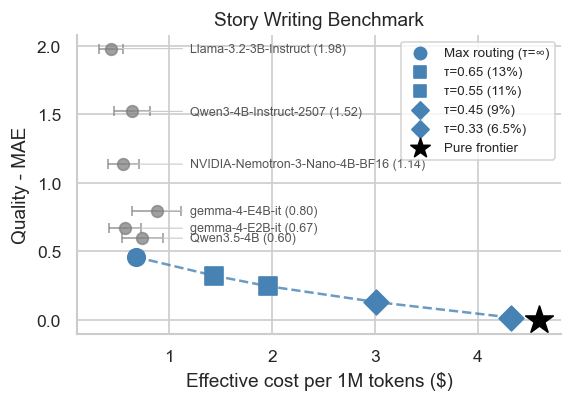

Saved pareto_story_writing_benchmark_mae.pdf


In [8]:
# Pareto figure - actual cost ($/1M) on x-axis
FIGURES_DIR = Path("../figures")

# Compute overall MAE per model from errors
model_mae = (
    errors.groupby("evaluator")["abs_err"].mean()
    .reset_index()
    .rename(columns={"evaluator": "model", "abs_err": "Overall MAE"})
)
model_info = cost_df[["model", "cost_mid", "cost_low", "cost_high"]].copy()
model_info = model_info.merge(model_mae, on="model", how="inner")
model_info = model_info.sort_values("Overall MAE", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(5, 3.5))

# --- Grey model dots with staggered labels ---
for _, row in model_info.iterrows():
    xerr = (row["cost_high"] - row["cost_low"]) / 2
    ax.errorbar(row["cost_mid"], row["Overall MAE"], xerr=xerr,
                fmt="o", color="grey", alpha=0.75, markersize=7,
                elinewidth=1, capsize=3, zorder=3)

x_label = model_info["cost_high"].max() + 0.08
label_ys = list(model_info["Overall MAE"])
min_gap = 0.05
for i in range(1, len(label_ys)):
    if label_ys[i - 1] - label_ys[i] < min_gap:
        label_ys[i] = label_ys[i - 1] - min_gap

for (_, row), ly in zip(model_info.iterrows(), label_ys):
    ax.annotate(
        f"{row['model']} ({row['Overall MAE']:.2f})",
        xy=(row["cost_mid"], row["Overall MAE"]),
        xytext=(x_label, ly),
        fontsize=7.5, color="#555", ha="left", va="center",
        arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.7),
    )

# --- MOJO operating points ---
marker_map = ["o", "s", "s", "D", "D"]
mojo_sorted = mojo_df.sort_values("blended_cost").reset_index(drop=True)
ax.plot(mojo_sorted["blended_cost"], mojo_sorted["realized_mae"],
        "--", color="steelblue", lw=1.5, alpha=0.8, zorder=2)

for i, row in mojo_sorted.iterrows():
    ax.scatter(row["blended_cost"], row["realized_mae"],
               s=110, marker=marker_map[i], color="steelblue", zorder=4,
               label=row["label"])

# --- Pure frontier ---
ax.scatter(CLAUDE_BLENDED, 0, marker="*", s=300, color="black", zorder=5,
           label="Pure frontier")

ax.set_xlabel("Effective cost per 1M tokens ($)")
ax.set_ylabel("Quality - MAE")
ax.set_title("Story Writing Benchmark")
ax.legend(fontsize=8, frameon=True, markerscale=0.7)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pareto_story_writing_benchmark_mae.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "pareto_story_writing_benchmark_mae.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved pareto_story_writing_benchmark_mae.pdf")

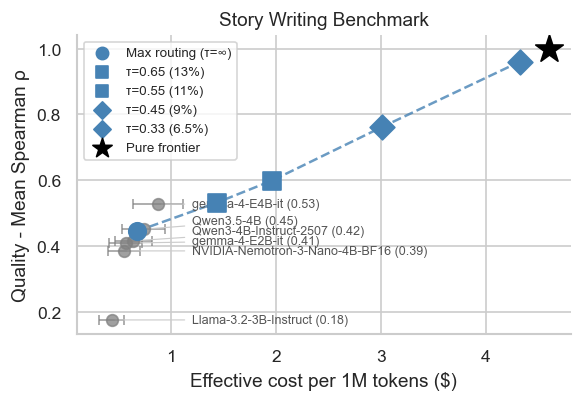

Saved pareto_story_writing_benchmark_rho.pdf


In [9]:
# Pareto figure - Spearman ρ on y-axis
model_rho = (
    rho_table.mean(axis=0)
    .reset_index()
    .rename(columns={"evaluator": "model", 0: "Mean Spearman rho"})
)
model_rho.columns = ["model", "Mean Spearman rho"]
model_info_rho = cost_df[["model", "cost_mid", "cost_low", "cost_high"]].copy()
model_info_rho = model_info_rho.merge(model_rho, on="model", how="inner")
model_info_rho = model_info_rho.sort_values("Mean Spearman rho").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(5, 3.5))

# --- Grey model dots ---
for _, row in model_info_rho.iterrows():
    xerr = (row["cost_high"] - row["cost_low"]) / 2
    ax.errorbar(row["cost_mid"], row["Mean Spearman rho"], xerr=xerr,
                fmt="o", color="grey", alpha=0.75, markersize=7,
                elinewidth=1, capsize=3, zorder=3)

x_label = model_info_rho["cost_high"].max() + 0.08
label_ys = list(model_info_rho["Mean Spearman rho"])
min_gap = 0.03
for i in range(1, len(label_ys)):
    if label_ys[i] - label_ys[i - 1] < min_gap:
        label_ys[i] = label_ys[i - 1] + min_gap

for (_, row), ly in zip(model_info_rho.iterrows(), label_ys):
    ax.annotate(
        f"{row['model']} ({row['Mean Spearman rho']:.2f})",
        xy=(row["cost_mid"], row["Mean Spearman rho"]),
        xytext=(x_label, ly),
        fontsize=7.5, color="#555", ha="left", va="center",
        arrowprops=dict(arrowstyle="-", color="#ccc", lw=0.7),
    )

# --- MOJO operating points ---
marker_map = ["o", "s", "s", "D", "D"]
mojo_sorted = mojo_df.sort_values("blended_cost").reset_index(drop=True)
ax.plot(mojo_sorted["blended_cost"], mojo_sorted["realized_rho"],
        "--", color="steelblue", lw=1.5, alpha=0.8, zorder=2)

for i, row in mojo_sorted.iterrows():
    ax.scatter(row["blended_cost"], row["realized_rho"],
               s=110, marker=marker_map[i], color="steelblue", zorder=4,
               label=row["label"])

# --- Pure frontier ---
ax.scatter(CLAUDE_BLENDED, 1.0, marker="*", s=300, color="black", zorder=5,
           label="Pure frontier")

ax.set_xlabel("Effective cost per 1M tokens ($)")
ax.set_ylabel("Quality - Mean Spearman ρ")
ax.set_title("Story Writing Benchmark")
ax.legend(fontsize=8, frameon=True, markerscale=0.7)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pareto_story_writing_benchmark_rho.pdf", bbox_inches="tight")
plt.savefig(FIGURES_DIR / "pareto_story_writing_benchmark_rho.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved pareto_story_writing_benchmark_rho.pdf")